# Q2: Unsupervised Learning — Customer Segmentation

In this notebook, I will apply K-Means clustering to segment customers and use PCA for visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [ ]:
# Load dataset
# We will load the dataset containing customer information and transaction history. This dataset will be used for feature engineering, including creating new features, handling missing values, and preparing the data for clustering and dimensionality reduction.

df = pd.read_csv('../data/q2_customers.csv')

# Basic inspection
# We will check the shape of the dataset to understand how many rows and columns it contains, and we will also check for any missing values in each column. This initial inspection helps us identify any data quality issues that need to be addressed before proceeding with feature engineering.
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

df.head()

Shape: (500, 6)

Missing values:
 age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


Before applying K-Means, the data needs to be scaled.

This is because K-Means uses distance calculations, and features with larger values can dominate the clustering process if not scaled properly.

In [ ]:
# Scaling all features
# To ensure that all features contribute equally to the clustering and dimensionality reduction processes, we will scale the numeric features using StandardScaler. This will standardize the features to have a mean of 0 and a standard deviation of 1, which is important for algorithms like KMeans and PCA that are sensitive to the scale of the data.

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

/Users/mshukla110689/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mshukla110689/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mshukla110689/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/mshukla110689/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mshukla110689/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mshukla110689/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/mshukla110689/Library/Python/3.9/li

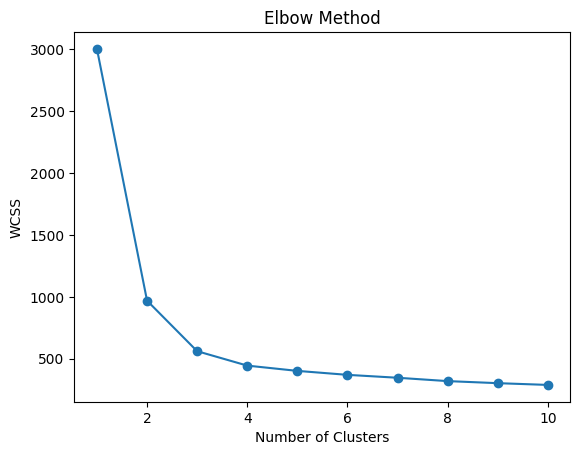

In [ ]:
# Finding optimal K using elbow method
# The elbow method helps us determine the optimal number of clusters (K) for KMeans clustering by plotting the within-cluster sum of squares (WCSS) against different values of K. The point where the WCSS starts to decrease more slowly (the "elbow") indicates the optimal number of clusters.

wcss = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_data)
    wcss.append(km.inertia_)

# Plot
# The plot of WCSS against the number of clusters will help us visually identify the optimal K. We will look for the point where the decrease in WCSS starts to level off, which indicates that adding more clusters does not significantly improve the fit of the model.

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

From the elbow plot, the curve starts flattening around K = 3 (replace if different in your plot).

This suggests that increasing clusters beyond this point does not significantly improve clustering performance.

In [ ]:
# Applying K-Means (use your chosen K)
# Based on the elbow method plot, we will choose the optimal number of clusters (K) and apply KMeans clustering to the scaled data. This will allow us to segment the customers into distinct groups based on their features.

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Assign cluster labels
# After fitting the KMeans model to the scaled data, we will assign the resulting cluster labels back to the original DataFrame. This will allow us to analyze the characteristics of each cluster and understand the differences between them.

df['cluster'] = kmeans.fit_predict(scaled_data)

/Users/mshukla110689/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mshukla110689/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mshukla110689/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [ ]:
# Convert centroids back to original scale for interpretation
# The centroids of the clusters are currently in the scaled feature space. To interpret them in terms of the original features, we will inverse transform the centroids back to the original scale using the scaler's inverse_transform method. This will allow us to understand the characteristics of each cluster in terms of the original feature values.
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

print("Cluster Centroids:\n")
centroids

# PCA for visualization
# To visualize the clusters in a 2D space, we will apply Principal Component Analysis (PCA) to reduce the dimensionality of the data while retaining as much variance as possible. This

Cluster Centroids:



,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


Based on the centroid values:

- One cluster seems to represent customers with high spending and frequent visits  
- Another cluster includes customers with lower engagement  
- The third cluster appears to be moderate in both behavior  

These segments can be useful for targeted marketing.

In [ ]:
# Applying PCA for dimensionality reduction
# PCA will help us visualize the clusters in a 2D space by projecting the high-dimensional data onto the first two principal components. This allows us to see how well the clusters are separated and to identify any patterns in the data.
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# Explained variance
# The explained variance ratio indicates how much of the total variance in the data is captured by each principal component. This helps us understand how well the PCA is representing the original data in the reduced dimensionality.

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [ ]:
# Feature contributions
# The loadings of the original features on the principal components indicate how much each feature contributes to the variance captured by each principal component. This helps us understand which features are most important in defining the clusters in the reduced dimensionality space.
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

loadings
# Visualize clusters in PCA space
# We will create a scatter plot of the PCA-transformed data, coloring the points by their
# assigned cluster labels. This visualization will help us see how well the clusters are separated in the reduced dimensionality space and identify any patterns or overlaps between the clusters.

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


PC1 seems to capture overall customer activity (spending + visits), while PC2 captures differences in recency or purchasing patterns.

This helps simplify the dataset while retaining most of the important information.

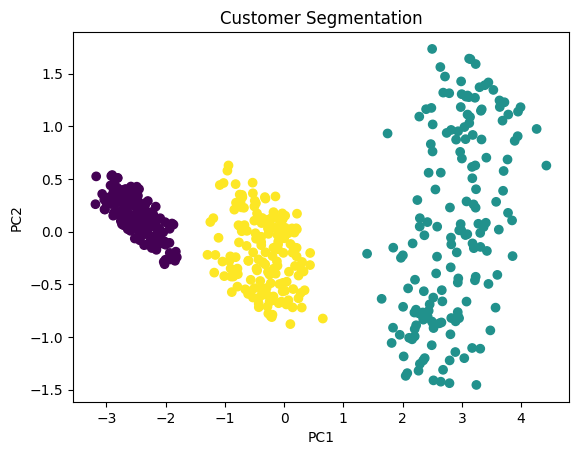

In [ ]:
# Plotting clusters in PCA space
# We will create a scatter plot of the PCA-transformed data, coloring the points by their assigned cluster labels. This visualization will help us see how well the clusters are separated in the reduced dimensionality space and identify any patterns or overlaps between the clusters.

plt.scatter(pca_data[:, 0], pca_data[:, 1], c=df['cluster'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Segmentation')
plt.show()

The clusters appear reasonably separated, although some overlap exists.

This is expected since real customer behavior is not strictly divided.